In [1]:
from spice.models import IcosphereModel
from spice.spectrum import Blackbody

bb = Blackbody()
star = IcosphereModel.construct(100, 1., 1., bb.solar_parameters, bb.parameter_names)
print(star.d_vertices.shape)

[spice] IcosphereModel constructed in 1.1 s
(312, 3)


In [2]:
import numpy as np
from spice.models import IcosphereModel
from spice.models.mesh_transform import add_rotation, evaluate_rotation
from spice.spectrum import simulate_observed_flux, Blackbody

bb = Blackbody()

# A solar-like star: ~1000 mesh vertices, 1 solar radius, 1 solar mass
star = IcosphereModel.construct(1000, 1., 1., bb.solar_parameters, bb.parameter_names)

# Solid-body rotation with a 2 km/s equatorial velocity
star = add_rotation(star, rotation_velocity=2.0)

# Now, the rotation has to be evaluated at a certain time.
# The choice of the timestep is not important here, as we have a homogeneous star

star_rotating = evaluate_rotation(star, t=0.0)

# simulate_observed_flux expects *log10* wavelengths (in Angstroms) and
# returns an (n_wavelengths, 2) array; column 0 is the flux in
# erg/s/cm^2/Angstrom at the default distance of 10 pc.
wavelengths = np.logspace(3, 4, 1000)  # 1,000-10,000 Angstroms
flux = simulate_observed_flux(bb.intensity, star_rotating, np.log10(wavelengths))

[spice] IcosphereModel constructed in 0.9 s


In [3]:
from spice.plots import plot_3D

plot_3D(star_rotating, property='los_velocities')

(<Figure size 1000x1200 with 2 Axes>,
 <Axes3D: xlabel='$X [R_\\odot]$', ylabel='$Y [R_\\odot]$', zlabel='$Z [R_\\odot]$'>)

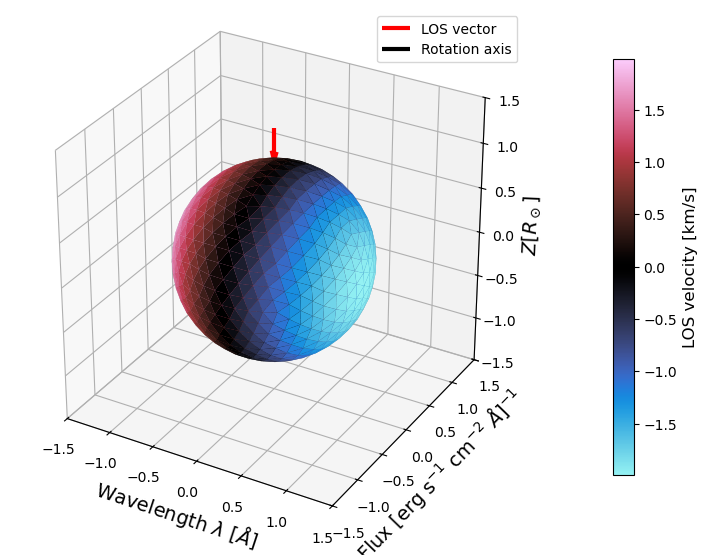

In [4]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
plt.plot(wavelengths, flux[:, 0], color='black')
plt.gca().set_xlabel(r'Wavelength $\lambda$ [$\AA$]')
plt.gca().set_ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ $\AA$]$^{-1}$')
plt.show()

In [5]:
import numpy as np
import jax.numpy as jnp
from spice.models import IcosphereModel, Binary
from spice.models.binary import add_orbit, evaluate_orbit_at_times
from spice.models.mesh_view import get_mesh_view
from spice.spectrum import simulate_observed_flux, Blackbody, AB_passband_luminosity
from spice.spectrum.filter import GaiaG

bb = Blackbody()
los = jnp.array([0.0, 0.0, -1.0])  # line of sight (observer -> star)

# Cast each component to the line of sight so occlusions can be resolved
primary = get_mesh_view(
    IcosphereModel.construct(1000, 1.0, 1.0, bb.solar_parameters, bb.parameter_names), los)
secondary = get_mesh_view(
    IcosphereModel.construct(1000, 0.8, 0.8, bb.solar_parameters, bb.parameter_names), los)

binary = Binary.from_bodies(primary, secondary)

# A close, edge-on system (P ~ 3.65 days) so the components actually eclipse
binary = add_orbit(
    binary,
    P=0.01,                   # orbital period [years]
    ecc=0.0,                  # eccentricity
    T=0.0,                    # time of periastron passage [years]
    i=np.pi / 2,              # inclination [rad], edge-on
    omega=0.0,                # argument of periastron [rad]
    Omega=0.0,                # longitude of the ascending node [rad]
    mean_anomaly=0.0,         # mean anomaly at the reference time [rad]
    reference_time=0.0,       # reference time [years]
    vgamma=0.0,               # systemic velocity [km/s]
    orbit_resolution_points=20,
)

# Evaluate the orbit across one period (eclipses/occlusions resolved internally)
times = jnp.linspace(0.0, 0.01, 20)
primaries, secondaries = evaluate_orbit_at_times(binary, times)

# Combined Gaia G-band light curve
wavelengths = np.linspace(900, 40000, 500)
gaia_g = GaiaG()
light_curve = [
    AB_passband_luminosity(
        gaia_g,
        wavelengths,
        simulate_observed_flux(bb.intensity, p1, np.log10(wavelengths))[:, 0]
        + simulate_observed_flux(bb.intensity, p2, np.log10(wavelengths))[:, 0],
    )
    for p1, p2 in zip(primaries, secondaries)
]

[spice] IcosphereModel constructed in 0.0 s
[spice] IcosphereModel constructed in 0.0 s
[spice] Binary orbit evaluated in 11.5 s


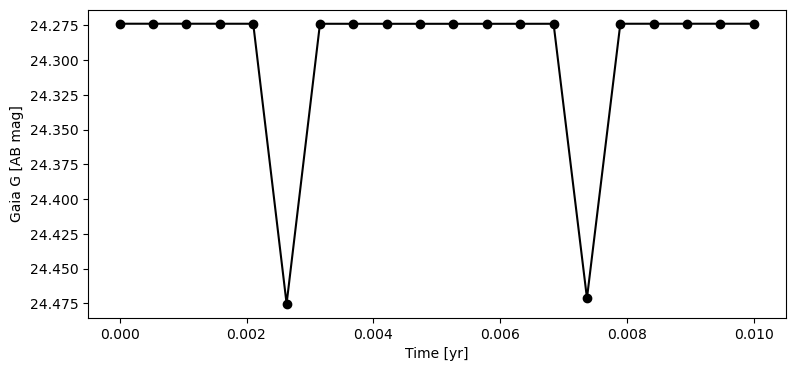

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.asarray(times), np.asarray(light_curve), "o-", color='black')
ax.invert_yaxis()  # magnitudes: smaller = brighter
ax.set_xlabel("Time [yr]")
ax.set_ylabel("Gaia G [AB mag]")
plt.show()

In [7]:
# Regenerate the documentation figures for docs/source/quickstart.rst
from pathlib import Path
from spice.plots import plot_3D

DOCS_IMG = Path("..") / ".." / "docs" / "img"

def save_doc_fig(name, make_fig):
    """Render ``make_fig()`` twice — default (light) style and dark style — and
    save as <name>.png / <name>_dark.png in docs/img."""
    for style, suffix in [("default", ""), ("dark_background", "_dark")]:
        with plt.style.context(style):
            fig = make_fig()
            fig.savefig(DOCS_IMG / f"{name}{suffix}.png", dpi=120, bbox_inches="tight",
                        facecolor=fig.get_facecolor())
            plt.close(fig)
    print(f"saved {name}.png / {name}_dark.png")

save_doc_fig("quickstart_rotating_mesh",
             lambda: plot_3D(star_rotating, property='los_velocities')[0])

def _spectrum_fig():
    wl_star = np.logspace(3, 4, 1000)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(wl_star, flux[:, 0])
    ax.set_xlabel(r'Wavelength $\lambda$ [$\AA$]')
    ax.set_ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]')
    return fig

save_doc_fig("quickstart_spectrum", _spectrum_fig)

def _light_curve_fig():
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(np.asarray(times), np.asarray(light_curve), "o-")
    ax.invert_yaxis()  # magnitudes: smaller = brighter
    ax.set_xlabel("Time [yr]")
    ax.set_ylabel("Gaia G [AB mag]")
    return fig

save_doc_fig("quickstart_light_curve", _light_curve_fig)

saved quickstart_rotating_mesh.png / quickstart_rotating_mesh_dark.png
saved quickstart_spectrum.png / quickstart_spectrum_dark.png
saved quickstart_light_curve.png / quickstart_light_curve_dark.png
